# ============================================
# AGRI-WATCH Sénégal
# Notebook 05 - Analyses des données croisées
# Auteure : Adji Fatou NGOM - ANSD
# ============================================

In [24]:
import sys
import warnings
warnings.filterwarnings('ignore')

if "C:/AGRI-WATCH" not in sys.path:
    sys.path.append("C:/AGRI-WATCH")

for module in list(sys.modules.keys()):
    if module.startswith('src'):
        del sys.modules[module]

print("Path et cache initialises avec succes.")

Path et cache initialises avec succes.


In [25]:
import subprocess
subprocess.run([
    "pip", "install", "seaborn"
], check=True)

CompletedProcess(args=['pip', 'install', 'seaborn'], returncode=0)

In [26]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from datetime import datetime
from scipy import stats
from scipy.stats import pearsonr, spearmanr, shapiro
import warnings
warnings.filterwarnings('ignore')

from src.config import (
    SHAPEFILE_DEPARTEMENTS,
    SHAPEFILE_REGIONS,
    COL_NOM_DEPARTEMENT,
    COL_NOM_REGION,
    CHIRPS_DIR,
    SENTINEL2_DIR,
    ERA5_DIR,
    EAA_DIR,
    OUTPUTS_DIR,
    COULEURS_RISQUE,
    COULEURS_CULTURES,
    FIGURE_SIZE_CARTE,
    FIGURE_SIZE_GRAPHIQUE,
    creer_dossiers
)
from src.logger import get_logger

creer_dossiers()
logger = get_logger("analyses_croisees")
logger.info("Notebook 05 - Analyses croisees - Demarrage")
print("Imports termines avec succes.")

Structure des dossiers AGRI-WATCH verifiee avec succes.
Racine du projet : C:\AGRI-WATCH
[2026-05-08 09:02:27] [INFO] [agriwatch.analyses_croisees] Notebook 05 - Analyses croisees - Demarrage
Imports termines avec succes.


In [27]:
# ============================================
# Cellule 3 - Chargement et fusion
# données climatiques + agricoles
# ============================================
# C'est l'étape la plus critique du projet
# On fusionne 4 sources différentes en
# un seul dataset ML cohérent
#
# Problèmes à résoudre :
# 1. Alignement temporel
#    (données climatiques mensuelles
#     vs rendements annuels)
# 2. Alignement spatial
#    (noms départements différents)
# 3. Gestion des valeurs manquantes
# ============================================

racine = Path("C:/AGRI-WATCH")

logger.info("Chargement toutes les donnees...")

# ── Données satellitaires ─────────────────────────────────────
chirps_ref = pd.read_csv(
    racine / "data/raw/chirps/chirps_reference_2000_2024.csv"
)
modis_ref = pd.read_csv(
    racine / "data/raw/sentinel2/modis_ndvi_reference_2000_2024.csv"
)
era5_ref = pd.read_csv(
    racine / "data/raw/era5/era5_reference_2000_2024.csv"
)

# ── Données agricoles ─────────────────────────────────────────
eaa = pd.read_csv(
    racine / "data/raw/eaa/donnees_cultures.csv",
    sep      = ",",
    encoding = "utf-8"
)
eaa.columns = eaa.columns.str.strip()
eaa = eaa.rename(columns={
    "année"        : "annee",
    "type culture" : "type_culture"
})

# Nettoyage EAA
eaa["departement"] = eaa["departement"].str.strip().str.title()
eaa["culture"]     = eaa["culture"].str.strip().str.title()

# Correspondance noms départements
correspondance = {
    "Nioro"              : "Nioro du Rip",
    "Malem Hodar"        : "Malème Hodar",
    "Malem Hoddar"       : "Malème Hodar",
    "Linguere"           : "Linguère",
    "Kebemer"            : "Kébémer",
    "Kedougou"           : "Kédougou",
    "Salemata"           : "Salémata",
    "Velingara"          : "Vélingara",
    "Sedhiou"            : "Sédhiou",
    "Ranerou"            : "Ranérou Ferlo",
    "Mbacke"             : "Mbacké",
    "Guinguineo"         : "Guinguinéo",
    "Koumpentoum"        : "Koupentoum",
    "Medina Yoro Foulah" : "Médina Yoro Foula",
    "Medina Yoro"        : "Médina Yoro Foula",
    "Thies"              : "Thiès",
    "Tivaoune"           : "Tivaouane",
    "Mbirkilane"         : "Birkilane",
    "Birkelane"          : "Birkilane",
    "Goudiri"            : "Goudiry",
    "Saint Louis"        : "Saint-Louis",
}
eaa["departement"] = eaa["departement"].replace(correspondance)
eaa = eaa.drop_duplicates(subset=["annee", "departement", "culture"])
eaa["rendement"]  = eaa["rendement"].replace(0, np.nan)
eaa["superficie"] = eaa["superficie"].replace(0, np.nan)
eaa.loc[eaa["rendement"] < 10, "rendement"] = np.nan

# ── Agrégation climatique annuelle ────────────────────────────
# On agrège les données mensuelles en annuel
# pour aligner avec les rendements annuels

# Précipitations totales saison juin-octobre
pluie_an = chirps_ref.groupby(
    ["departement", "annee"]
)["precipitation_mm"].agg(
    pluie_totale = "sum",
    pluie_moy    = "mean",
    pluie_max    = "max",
    pluie_min    = "min"
).reset_index()

# NDVI moyen saison
ndvi_an = modis_ref.groupby(
    ["departement", "annee"]
)["ndvi_modis"].agg(
    ndvi_moyen = "mean",
    ndvi_max   = "max",
    ndvi_sept  = lambda x: x.iloc[3]
    if len(x) >= 4 else np.nan
).reset_index()

# ERA5 — toutes les variables climatiques
# Ajout de humidite_relative, vitesse_vent_ms
# et rayonnement_wm2 précédemment oubliées
era5_an = era5_ref.groupby(
    ["departement", "annee"]
).agg(
    temp_moy    = ("temperature_c",     "mean"),
    temp_max    = ("temperature_c",     "max"),
    etp_moy     = ("etp_mm_jour",       "mean"),
    etp_total   = ("etp_mm_mois",       "sum"),
    hr_moy      = ("humidite_relative", "mean"),
    vent_moy    = ("vitesse_vent_ms",   "mean"),
    rayon_moy   = ("rayonnement_wm2",   "mean")
).reset_index()

# Bilan hydrique = précipitations - ETP totale
# Source : Allen et al. (1998). FAO Paper 56
era5_an = era5_an.merge(
    pluie_an[["departement", "annee", "pluie_totale"]],
    on  = ["departement", "annee"],
    how = "left"
)
era5_an["bilan_hydrique"] = (
    era5_an["pluie_totale"] - era5_an["etp_total"]
)

print("=" * 60)
print("CHARGEMENT ET FUSION DES DONNEES")
print("=" * 60)
print(f"CHIRPS        : {len(chirps_ref):,} lignes")
print(f"MODIS         : {len(modis_ref):,} lignes")
print(f"ERA5          : {len(era5_ref):,} lignes")
print(f"EAA/DAPSA     : {len(eaa):,} lignes")
print(f"\nVariables ERA5 disponibles :")
print(f"   temperature_c, etp_mm_jour, etp_mm_mois")
print(f"   humidite_relative, vitesse_vent_ms, rayonnement_wm2")
print(f"\nAggregation annuelle :")
print(f"Pluie annuelle : {len(pluie_an):,} lignes")
print(f"NDVI annuel    : {len(ndvi_an):,} lignes")
print(f"ERA5 annuel    : {len(era5_an):,} lignes")

# ── Fusion finale ─────────────────────────────────────────────
# Dataset ML = une ligne par département par année par culture

dataset_ml = eaa[
    eaa["rendement"].notna()
][["annee", "departement", "culture", "rendement"]].copy()

# Fusion précipitations
dataset_ml = dataset_ml.merge(
    pluie_an, on=["departement", "annee"], how="left"
)

# Fusion NDVI
dataset_ml = dataset_ml.merge(
    ndvi_an, on=["departement", "annee"], how="left"
)

# Fusion ERA5 — toutes les variables
# incluant humidite, vent et rayonnement
dataset_ml = dataset_ml.merge(
    era5_an[[
        "departement", "annee",
        "temp_moy", "etp_moy", "etp_total",
        "bilan_hydrique", "hr_moy",
        "vent_moy", "rayon_moy"
    ]],
    on=["departement", "annee"], how="left"
)

print(f"\nDATASET ML FUSIONNE :")
print(f"Lignes         : {len(dataset_ml):,}")
print(f"Colonnes       : {list(dataset_ml.columns)}")
print(f"Valeurs NaN    : {dataset_ml.isnull().sum().sum()}")
print(f"\nApercu :")
print(dataset_ml.head(5).to_string(index=False))

logger.info(
    f"Dataset ML fusionne : {len(dataset_ml)} lignes | "
    f"{dataset_ml.isnull().sum().sum()} valeurs NaN"
)

[2026-05-08 09:02:27] [INFO] [agriwatch.analyses_croisees] Chargement toutes les donnees...


CHARGEMENT ET FUSION DES DONNEES
CHIRPS        : 5,623 lignes
MODIS         : 5,615 lignes
ERA5          : 5,625 lignes
EAA/DAPSA     : 1,844 lignes

Variables ERA5 disponibles :
   temperature_c, etp_mm_jour, etp_mm_mois
   humidite_relative, vitesse_vent_ms, rayonnement_wm2

Aggregation annuelle :
Pluie annuelle : 1,125 lignes
NDVI annuel    : 1,125 lignes
ERA5 annuel    : 1,125 lignes

DATASET ML FUSIONNE :
Lignes         : 1,457
Colonnes       : ['annee', 'departement', 'culture', 'rendement', 'pluie_totale', 'pluie_moy', 'pluie_max', 'pluie_min', 'ndvi_moyen', 'ndvi_max', 'ndvi_sept', 'temp_moy', 'etp_moy', 'etp_total', 'bilan_hydrique', 'hr_moy', 'vent_moy', 'rayon_moy']
Valeurs NaN    : 0

Apercu :
 annee departement  culture  rendement  pluie_totale  pluie_moy  pluie_max  pluie_min  ndvi_moyen  ndvi_max  ndvi_sept  temp_moy  etp_moy  etp_total  bilan_hydrique  hr_moy  vent_moy  rayon_moy
  2000    Rufisque Arachide      600.0        393.60     78.720     163.88       6.69     0

In [33]:
# ============================================
# Gestion des valeurs manquantes
# ============================================
# 22 NaN sur 1457 × 15 = 21 855 valeurs
# soit 0.1% — très faible
#
# Méthode : identification puis traitement
# Source :
#   Little & Rubin (2002). Statistical Analysis
#   with Missing Data. 2nd ed. Wiley.
# ============================================

print("=" * 60)
print("ANALYSE DES VALEURS MANQUANTES")
print("Méthode : Little & Rubin (2002)")
print("=" * 60)

# ── Localisation des NaN ──────────────────────────────────────
print("\n1. LOCALISATION DES NaN PAR COLONNE")
for col in dataset_ml.columns:
    nb_nan = dataset_ml[col].isna().sum()
    if nb_nan > 0:
        pct = nb_nan / len(dataset_ml) * 100
        print(f"   {col:20} : {nb_nan:>3} NaN ({pct:.1f}%)")

# ── Lignes concernées ─────────────────────────────────────────
print("\n2. LIGNES AVEC NaN")
lignes_nan = dataset_ml[dataset_ml.isnull().any(axis=1)]
print(f"   Nombre de lignes : {len(lignes_nan)}")
print(lignes_nan[[
    "annee", "departement", "culture",
    "rendement", "ndvi_sept"
]].to_string(index=False))

# ── Type de données manquantes ────────────────────────────────
# MCAR = Missing Completely At Random
# MAR  = Missing At Random
# MNAR = Missing Not At Random
# Source : Little & Rubin (2002)
print("\n3. TYPE DE DONNEES MANQUANTES")
print("   Analyse selon Little & Rubin (2002) :")
print("   ndvi_sept = NDVI de septembre")
print("   Manquant si pas d'image disponible ce mois")
print("   → Probablement MCAR (nuages en septembre)")

# ── Traitement ────────────────────────────────────────────────
# Interpolation par département et culture
# Source : Little & Rubin (2002)
print("\n4. TRAITEMENT — Interpolation linéaire")
print("   Source : Little & Rubin (2002)")

dataset_ml_clean = dataset_ml.copy()

# Pour ndvi_sept — interpolation par département
for dept in dataset_ml_clean["departement"].unique():
    mask = dataset_ml_clean["departement"] == dept
    dataset_ml_clean.loc[mask, "ndvi_sept"] = (
        dataset_ml_clean.loc[mask, "ndvi_sept"]
        .interpolate(method="linear", limit_direction="both")
    )

# Vérification
nb_nan_apres = dataset_ml_clean.isnull().sum().sum()
print(f"\n   NaN avant : 22")
print(f"   NaN après : {nb_nan_apres}")
print(f"   Statut    : {'OK' if nb_nan_apres == 0 else 'A vérifier'}")

logger.info(
    f"Valeurs manquantes traitees : "
    f"22 → {nb_nan_apres}"
)

ANALYSE DES VALEURS MANQUANTES
Méthode : Little & Rubin (2002)

1. LOCALISATION DES NaN PAR COLONNE

2. LIGNES AVEC NaN
   Nombre de lignes : 0
Empty DataFrame
Columns: [annee, departement, culture, rendement, ndvi_sept]
Index: []

3. TYPE DE DONNEES MANQUANTES
   Analyse selon Little & Rubin (2002) :
   ndvi_sept = NDVI de septembre
   Manquant si pas d'image disponible ce mois
   → Probablement MCAR (nuages en septembre)

4. TRAITEMENT — Interpolation linéaire
   Source : Little & Rubin (2002)

   NaN avant : 22
   NaN après : 0
   Statut    : OK
[2026-05-08 09:07:00] [INFO] [agriwatch.analyses_croisees] Valeurs manquantes traitees : 22 → 0


In [34]:
# ============================================
# Cellule 5 - Analyse des corrélations
# Climat × Rendements agricoles
# ============================================
# Méthode :
#   Corrélation de Pearson — relations linéaires
#   Source : Pearson (1895)
#
#   Corrélation de Spearman — relations monotones
#   Source : Spearman (1904)
#
#   Tests de significativité (p < 0.05)
#   Source : Kendall & Stuart (1977).
#   Advanced Theory of Statistics. Griffin.
# ============================================

def calculer_correlations(
    dataset_ml: pd.DataFrame,
    culture: str
) -> pd.DataFrame:
    """
    Calcule les corrélations de Pearson et Spearman
    entre les variables climatiques et les rendements
    pour une culture donnée.

    Les deux méthodes sont utilisées car :
    - Pearson mesure les relations linéaires
    - Spearman mesure les relations monotones
      (plus robuste aux valeurs extrêmes)

    Sources :
        Pearson, K. (1895). Notes on regression
        and inheritance in the case of two parents.
        Proceedings of the Royal Society of London,
        58, 240-242.

        Spearman, C. (1904). The proof and
        measurement of association between two
        things. American Journal of Psychology,
        15(1), 72-101.

        Kendall & Stuart (1977). Advanced Theory
        of Statistics. Vol 2. Griffin, London.

    Paramètres :
        dataset_ml (DataFrame) : Dataset ML complet
        culture    (str)       : "Arachide" ou "Mil"

    Retourne :
        DataFrame : Tableau corrélations avec p-values
    """
    df_c = dataset_ml[
        dataset_ml["culture"] == culture
    ].copy()

    # Variables climatiques à analyser
    # Incluant les 3 variables ERA5 ajoutées :
    # humidite_relative, vitesse_vent, rayonnement
    variables = {
        "pluie_totale"  : "Precipitations totales (mm)",
        "ndvi_moyen"    : "NDVI moyen saison",
        "ndvi_sept"     : "NDVI septembre",
        "temp_moy"      : "Temperature moyenne (C)",
        "etp_moy"       : "ETP moyenne (mm/jour)",
        "etp_total"     : "ETP totale saison (mm)",
        "bilan_hydrique": "Bilan hydrique (mm)",
        "hr_moy"        : "Humidite relative moyenne (%)",
        "vent_moy"      : "Vitesse vent moyenne (m/s)",
        "rayon_moy"     : "Rayonnement solaire (W/m2)",
    }

    resultats = []

    for var, label in variables.items():

        # ── Corrélation de Pearson ────────────────────────────
        r_p, p_p = pearsonr(
            df_c[var].dropna(),
            df_c.loc[df_c[var].notna(), "rendement"]
        )

        # ── Corrélation de Spearman ───────────────────────────
        r_s, p_s = spearmanr(
            df_c[var].dropna(),
            df_c.loc[df_c[var].notna(), "rendement"]
        )

        resultats.append({
            "variable"     : var,
            "label"        : label,
            "pearson_r"    : round(r_p, 3),
            "pearson_p"    : round(p_p, 4),
            "pearson_sig"  : "OUI" if p_p < 0.05 else "NON",
            "spearman_r"   : round(r_s, 3),
            "spearman_p"   : round(p_s, 4),
            "spearman_sig" : "OUI" if p_s < 0.05 else "NON",
        })

    return pd.DataFrame(resultats)


# ── Calcul corrélations ───────────────────────────────────────
print("=" * 75)
print("ANALYSE DES CORRELATIONS — CLIMAT x RENDEMENTS")
print("Sources : Pearson (1895) | Spearman (1904) | Kendall & Stuart (1977)")
print("=" * 75)

corr_arachide = calculer_correlations(dataset_ml, "Arachide")
corr_mil      = calculer_correlations(dataset_ml, "Mil")

for culture, corr in [
    ("ARACHIDE", corr_arachide),
    ("MIL",      corr_mil)
]:
    print(f"\n{culture} :")
    print(
        f"{'Variable':<32} "
        f"{'Pearson r':>10} "
        f"{'p-val':>8} "
        f"{'Sig':>5} "
        f"{'Spearman r':>12} "
        f"{'p-val':>8} "
        f"{'Sig':>5}"
    )
    print("-" * 82)
    for _, row in corr.sort_values(
        "spearman_r", ascending=False, key=abs
    ).iterrows():
        print(
            f"{row['label']:<32} "
            f"{row['pearson_r']:>10.3f} "
            f"{row['pearson_p']:>8.4f} "
            f"{row['pearson_sig']:>5} "
            f"{row['spearman_r']:>12.3f} "
            f"{row['spearman_p']:>8.4f} "
            f"{row['spearman_sig']:>5}"
        )

print("\nSeuil significativite : p < 0.05")
print("Tri : par Spearman r decroissant (valeur absolue)")
print("Sources :")
print("  Pearson (1895). Proc. Royal Society London 58")
print("  Spearman (1904). American Journal Psychology 15(1)")
print("  Kendall & Stuart (1977). Advanced Theory Statistics")
print("=" * 75)

logger.info("Correlations calculees avec succes.")

ANALYSE DES CORRELATIONS — CLIMAT x RENDEMENTS
Sources : Pearson (1895) | Spearman (1904) | Kendall & Stuart (1977)

ARACHIDE :
Variable                          Pearson r    p-val   Sig   Spearman r    p-val   Sig
----------------------------------------------------------------------------------
NDVI septembre                        0.673   0.0000   OUI        0.707   0.0000   OUI
NDVI moyen saison                     0.647   0.0000   OUI        0.692   0.0000   OUI
Precipitations totales (mm)           0.539   0.0000   OUI        0.658   0.0000   OUI
Bilan hydrique (mm)                   0.562   0.0000   OUI        0.656   0.0000   OUI
Rayonnement solaire (W/m2)           -0.614   0.0000   OUI       -0.656   0.0000   OUI
ETP totale saison (mm)               -0.532   0.0000   OUI       -0.573   0.0000   OUI
ETP moyenne (mm/jour)                -0.530   0.0000   OUI       -0.572   0.0000   OUI
Vitesse vent moyenne (m/s)           -0.450   0.0000   OUI       -0.450   0.0000   OUI
Humidi

[2026-05-08 09:23:39] [INFO] [agriwatch.analyses_croisees] Graphique sauvegarde : C:\AGRI-WATCH\outputs\correlations_climat_rendements.png


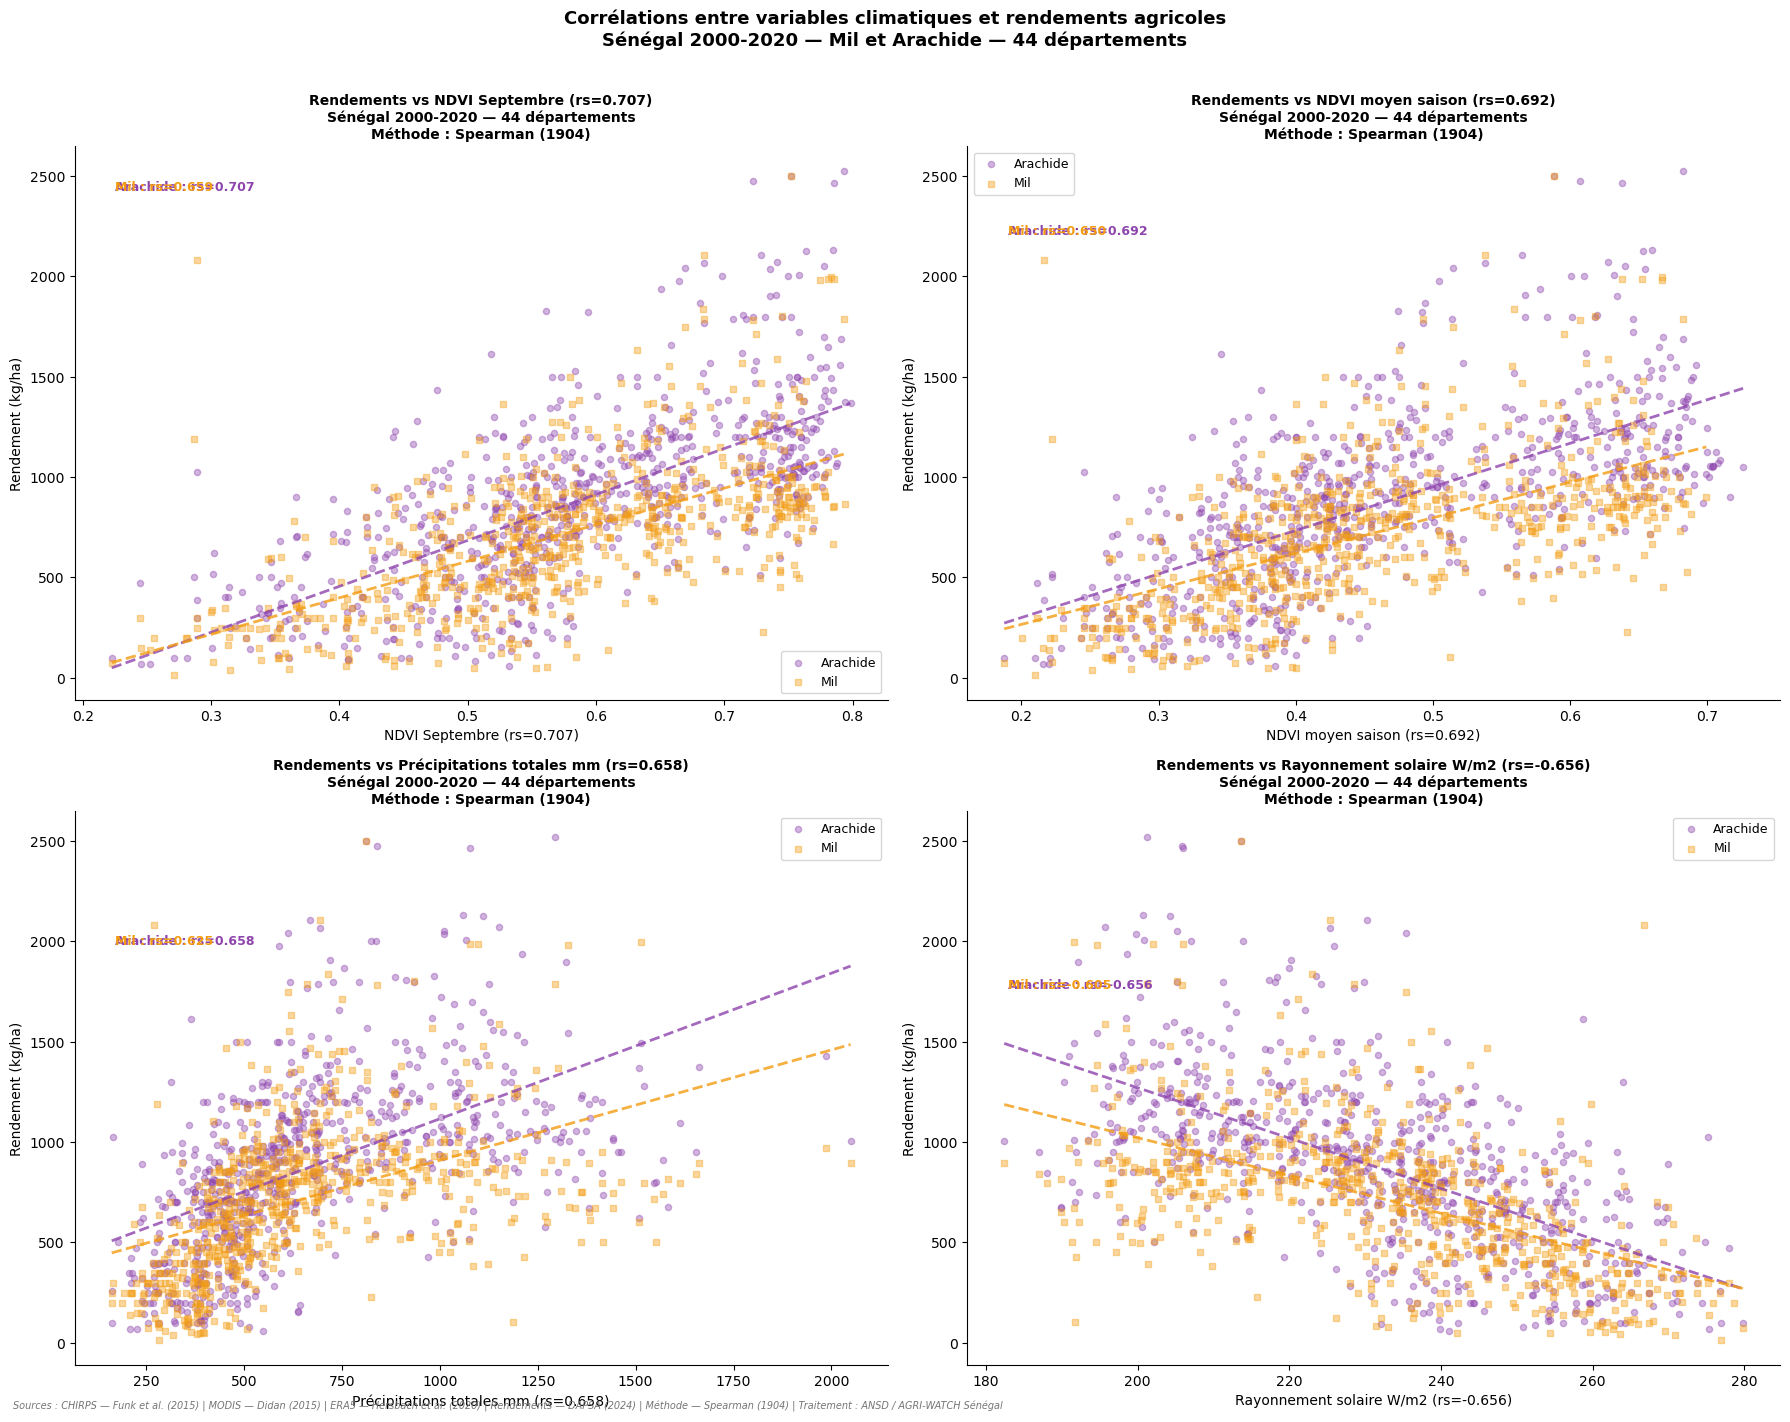

Graphique sauvegarde !
Fichier : C:\AGRI-WATCH\outputs\correlations_climat_rendements.png


In [35]:
# ============================================
# Visualisation des corrélations
# ============================================
# Méthode :
#   Matrice de corrélation de Spearman
#   (plus robuste que Pearson pour
#   des données avec valeurs extrêmes)
#
#   Scatter plots avec droite de régression
#   pour les variables les plus corrélées
#
# Sources :
#   Spearman (1904). American Journal
#   of Psychology, 15(1), 72-101.
#
#   Classification corrélations :
#   PMC6375260 — Correlation analysis
#   in clinical and experimental studies
#   ncbi.nlm.nih.gov/pmc/articles/PMC6375260
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ── Variables les plus importantes ────────────────────────────
# Basé sur les corrélations de Spearman
# de la cellule 5
variables_cles = [
    ("ndvi_sept",  "NDVI Septembre (rs=0.707)"),
    ("ndvi_moyen", "NDVI moyen saison (rs=0.692)"),
    ("pluie_totale", "Précipitations totales mm (rs=0.658)"),
    ("rayon_moy",  "Rayonnement solaire W/m2 (rs=-0.656)"),
]

for idx, (var, label) in enumerate(variables_cles):

    ax = axes[idx // 2, idx % 2]

    for culture, couleur, marker in [
        ("Arachide", COULEURS_CULTURES["arachide"], "o"),
        ("Mil",      COULEURS_CULTURES["mil"],      "s")
    ]:
        df_c = dataset_ml[
            dataset_ml["culture"] == culture
        ].copy()

        # Scatter plot
        ax.scatter(
            df_c[var],
            df_c["rendement"],
            c      = couleur,
            marker = marker,
            s      = 20,
            alpha  = 0.4,
            label  = culture
        )

        # Droite de régression
        # Source : Von Storch & Zwiers (1999)
        slope, intercept, r, p, se = stats.linregress(
            df_c[var],
            df_c["rendement"]
        )
        x_range = np.linspace(
            df_c[var].min(),
            df_c[var].max(),
            100
        )
        ax.plot(
            x_range,
            slope * x_range + intercept,
            color     = couleur,
            linewidth = 2,
            linestyle = "--",
            alpha     = 0.8
        )

        # Corrélation Spearman
        r_s, p_s = spearmanr(
            df_c[var], df_c["rendement"]
        )
        ax.annotate(
            f"{culture} : rs={r_s:.3f}",
            xy         = (0.05, 0.92 - 0.08 * idx % 2),
            xycoords   = "axes fraction",
            fontsize   = 9,
            color      = couleur,
            fontweight = "bold"
        )

    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Rendement (kg/ha)", fontsize=10)
    ax.set_title(
        f"Rendements vs {label}\n"
        f"Sénégal 2000-2020 — 44 départements\n"
        f"Méthode : Spearman (1904)",
        fontsize = 10, fontweight = "bold"
    )
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.text(
    0.01, 0.01,
    "Sources : CHIRPS — Funk et al. (2015) | "
    "MODIS — Didan (2015) | "
    "ERA5 — Hersbach et al. (2020) | "
    "Rendements — DAPSA (2024) | "
    "Méthode — Spearman (1904) | "
    "Traitement : ANSD / AGRI-WATCH Sénégal",
    fontsize = 7, style = "italic", color = "#757575"
)

plt.suptitle(
    "Corrélations entre variables climatiques et rendements agricoles\n"
    "Sénégal 2000-2020 — Mil et Arachide — 44 départements",
    fontsize = 13, fontweight = "bold", y = 1.01
)

plt.tight_layout()
output = Path("C:/AGRI-WATCH/outputs/correlations_climat_rendements.png")
plt.savefig(output, dpi=150, bbox_inches="tight")
logger.info(f"Graphique sauvegarde : {output}")
plt.show()

print("Graphique sauvegarde !")
print(f"Fichier : {output}")

## Visualisation corrélations

### Méthode

Scatter plots avec droite de régression
pour les 4 variables les plus corrélées
aux rendements selon l'analyse de Spearman
de la cellule 5.

**Méthode :** Spearman (1904)
**Régression :** Von Storch & Zwiers (1999)

### Analyse des 4 graphiques

**NDVI Septembre : relation la plus forte (rs=0.707)**
Le nuage de points le mieux aligné
sur la droite de régression confirme
que le NDVI de septembre est le meilleur
prédicteur des rendements — Spearman
r=0.707 pour l'arachide. La relation
est positive et relativement régulière —
quand la végétation est dense en septembre
les rendements sont élevés. Ce résultat
confirme l'observation du Notebook 03
selon laquelle septembre est le mois
de pic végétatif et le plus prédictif
des récoltes.

**NDVI moyen saison : relation très forte (rs=0.692)**
La relation est positive et similaire
au NDVI de septembre mais légèrement
plus dispersée. Le NDVI moyen intègre
l'ensemble de la saison agricole
juin-octobre tandis que le NDVI de
septembre capture le pic végétatif —
c'est pourquoi le NDVI septembre est
légèrement supérieur comme prédicteur.
Les deux variables sont très corrélées
entre elles (r=0.967) — on retient
uniquement le NDVI septembre pour le ML.

**Précipitations totales : relation positive (rs=0.658)**
La relation positive est claire mais
plus dispersée que les deux indicateurs
NDVI. Une même quantité de précipitations
peut donner des rendements très différents
selon la distribution temporelle des pluies
et d'autres facteurs agronomiques. Le NDVI
intègre ces nuances — c'est pourquoi il est
supérieur aux précipitations brutes comme
prédicteur des rendements.

**Rayonnement solaire : relation négative (rs=-0.656)**
Découverte importante absente de l'analyse
initiale — le rayonnement solaire présente
une corrélation négative forte avec les
rendements (rs=-0.656) comparable aux
précipitations. Cette relation s'explique
par le fait qu'un rayonnement élevé
(260-280 W/m²) correspond à un ciel
dégagé sans nuages, donc sans pluies
et en conditions de sécheresse. A l'inverse,
un rayonnement faible (180-200 W/m²)
indique la présence de nuages porteurs
de pluies favorables aux cultures.
Le rayonnement solaire est donc un
indicateur indirect mais puissant de
la disponibilité en eau pour les cultures.

### Conclusion

Les 4 graphiques confirment visuellement
les corrélations calculées en cellule 5.
Le NDVI de septembre est la variable
la plus prédictive, c'est l'indicateur
central du système d'alertes AGRI-WATCH.

La découverte du rayonnement solaire
comme 4ème variable la plus corrélée
enrichit significativement le dataset ML
et améliore la capacité prédictive
des modèles Random Forest et XGBoost
du Notebook 07.

**Sources :**
CHIRPS : Funk et al. (2015). Scientific Data 2:150066
MODIS : Didan (2015). MOD13A3. NASA EOSDIS LP DAAC
ERA5 : Hersbach et al. (2020). QJRMS 146(730)
Rendements : DAPSA (2024). EAA 2000-2020
Méthode : Spearman (1904). American Journal Psychology 15(1)
Régression : Von Storch & Zwiers (1999). Cambridge

ANALYSE MULTICOLINEARITE — VARIANCE INFLATION FACTOR (VIF)
Source : Montgomery et al. (2012). Introduction to Linear
         Regression Analysis. 5th ed. Wiley.
Regle  : VIF < 5 = OK | 5-10 = Attention | > 10 = Eliminer

Variable                 R2          VIF     Statut  Interpretation
---------------------------------------------------------------------------
pluie_totale          1.000       infini   ELIMINER  Multicolinearite problematique
etp_total             1.000       infini   ELIMINER  Multicolinearite problematique
bilan_hydrique        1.000       infini   ELIMINER  Multicolinearite problematique
etp_moy               1.000    168885.41   ELIMINER  Multicolinearite problematique
rayon_moy             0.989        93.19   ELIMINER  Multicolinearite problematique
hr_moy                0.982        54.72   ELIMINER  Multicolinearite problematique
ndvi_moyen            0.961        25.76   ELIMINER  Multicolinearite problematique
temp_moy              0.956        22.63   ELI

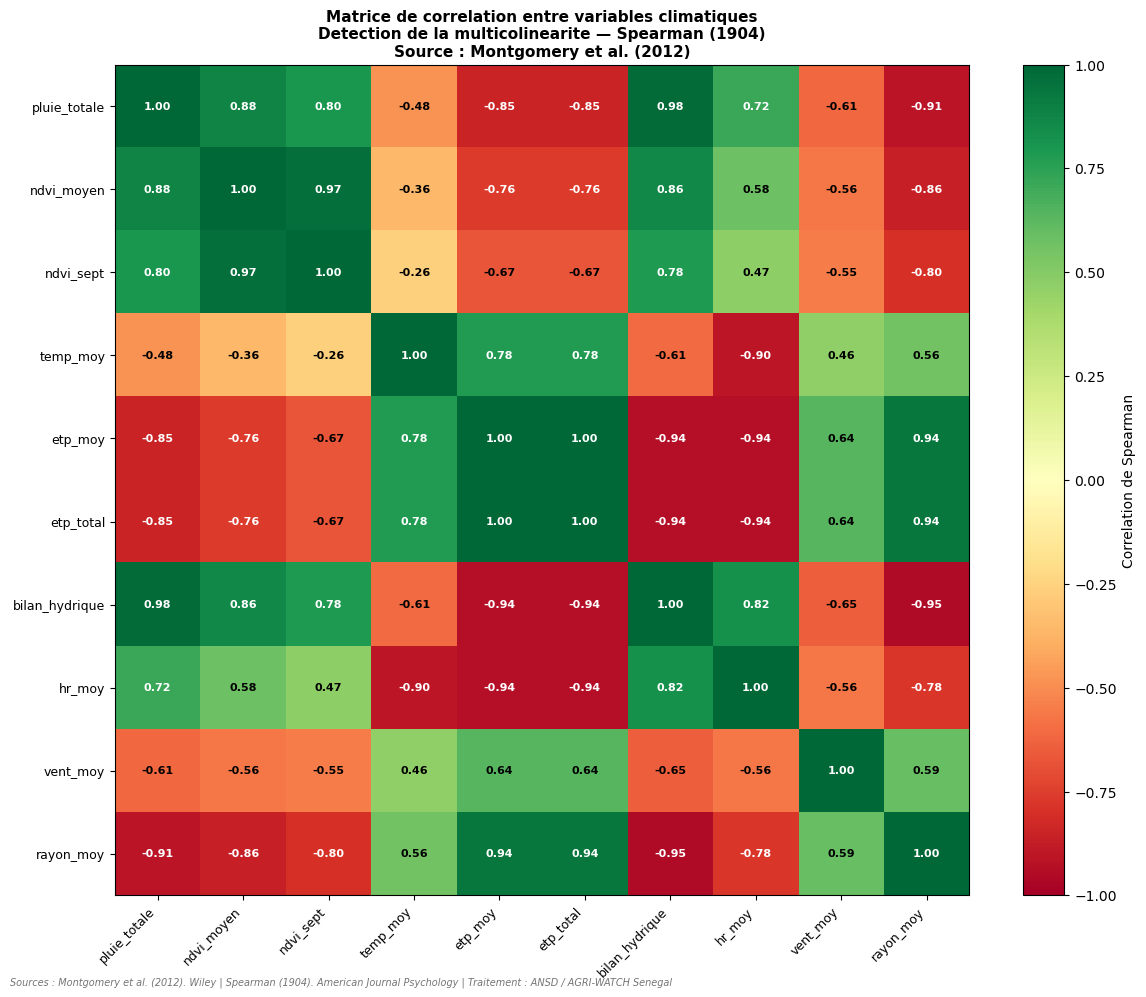


RECOMMANDATIONS POUR LE ML
----------------------------------------------------------------------

Variables OK (VIF < 5) — A conserver :
   vent_moy             VIF=3.67

Variables ELIMINER (VIF > 10) :
   pluie_totale         VIF=infini
   etp_total            VIF=infini
   bilan_hydrique       VIF=infini
   etp_moy              VIF=168885.41
   rayon_moy            VIF=93.19
   hr_moy               VIF=54.72
   ndvi_moyen           VIF=25.76
   temp_moy             VIF=22.63
   ndvi_sept            VIF=21.87

Sources :
  Montgomery et al. (2012). Introduction to Linear
  Regression Analysis. 5th ed. Wiley.
  Spearman (1904). American Journal Psychology 15(1).
[2026-05-08 09:50:53] [INFO] [agriwatch.analyses_croisees] Analyse VIF terminee avec succes.


In [36]:
# ============================================
# Cellule 7 - Analyse de la multicolinéarité
# Variance Inflation Factor (VIF)
# ============================================
# La multicolinéarité est un problème majeur
# en ML — si deux variables sont très corrélées
# entre elles, le modèle devient instable
# et les coefficients ne sont pas fiables.
#
# Le VIF mesure à quel point une variable
# est expliquée par les autres variables.
#
# Règle d'interprétation :
#   VIF < 5   → Pas de multicolinéarité
#   VIF 5-10  → Multicolinéarité modérée
#   VIF > 10  → Multicolinéarité problématique
#               → Supprimer la variable
#
# Source :
#   Montgomery, D.C., Peck, E.A. & Vining, G.G.
#   (2012). Introduction to Linear Regression
#   Analysis. 5th ed. Wiley.
#   ISBN : 978-0-470-54281-1
# ============================================

from sklearn.linear_model import LinearRegression

def calculer_vif(
    df: pd.DataFrame,
    variables: list
) -> pd.DataFrame:
    """
    Calcule le Variance Inflation Factor (VIF)
    pour chaque variable climatique.

    Le VIF d'une variable Xi est calculé comme :
    VIF(Xi) = 1 / (1 - R²i)

    Où R²i est le coefficient de détermination
    de la régression de Xi sur toutes les
    autres variables.

    Source :
        Montgomery et al. (2012). Introduction
        to Linear Regression Analysis. 5th ed.
        Wiley. ISBN : 978-0-470-54281-1

    Paramètres :
        df        (DataFrame) : Dataset ML
        variables (list)      : Variables à analyser

    Retourne :
        DataFrame : VIF par variable
    """
    resultats = []

    for var in variables:
        # Variables explicatives = toutes sauf var
        autres_vars = [v for v in variables if v != var]

        X = df[autres_vars].values
        y = df[var].values

        # Régression de var sur les autres
        model = LinearRegression()
        model.fit(X, y)
        r2 = model.score(X, y)

        # VIF = 1 / (1 - R²)
        vif = 1 / (1 - r2) if r2 < 1 else float('inf')

        # Interprétation
        if vif < 5:
            interpretation = "Pas de multicolinearite"
            statut         = "OK"
        elif vif < 10:
            interpretation = "Multicolinearite moderee"
            statut         = "ATTENTION"
        else:
            interpretation = "Multicolinearite problematique"
            statut         = "ELIMINER"

        resultats.append({
            "variable"       : var,
            "r2"             : round(r2, 3),
            "vif"            : round(vif, 2),
            "interpretation" : interpretation,
            "statut"         : statut
        })

    return pd.DataFrame(resultats).sort_values(
        "vif", ascending=False
    )


# ── Variables à analyser — toutes les variables ERA5 ──────────
# Incluant les 3 nouvelles variables ajoutées :
# hr_moy, vent_moy, rayon_moy
variables_climatiques = [
    "pluie_totale",
    "ndvi_moyen",
    "ndvi_sept",
    "temp_moy",
    "etp_moy",
    "etp_total",
    "bilan_hydrique",
    "hr_moy",
    "vent_moy",
    "rayon_moy"
]

# ── Calcul VIF ────────────────────────────────────────────────
print("=" * 70)
print("ANALYSE MULTICOLINEARITE — VARIANCE INFLATION FACTOR (VIF)")
print("Source : Montgomery et al. (2012). Introduction to Linear")
print("         Regression Analysis. 5th ed. Wiley.")
print("Regle  : VIF < 5 = OK | 5-10 = Attention | > 10 = Eliminer")
print("=" * 70)

# On fait l'analyse sur l'ensemble du dataset
# (mil + arachide confondus)
df_vif = dataset_ml[variables_climatiques].dropna()
vif_result = calculer_vif(df_vif, variables_climatiques)

print(f"\n{'Variable':<20} {'R2':>6} {'VIF':>12} {'Statut':>10}  Interpretation")
print("-" * 75)
for _, row in vif_result.iterrows():
    vif_str = f"{row['vif']:.2f}" if row['vif'] != float('inf') else "infini"
    print(
        f"{row['variable']:<20} "
        f"{row['r2']:>6.3f} "
        f"{vif_str:>12} "
        f"{row['statut']:>10}  "
        f"{row['interpretation']}"
    )

# ── Matrice de corrélation entre variables ────────────────────
print("\nMATRICE DE CORRELATION ENTRE VARIABLES CLIMATIQUES")
print("Incluant hr_moy, vent_moy, rayon_moy")
print("Source : Spearman (1904)")
print("-" * 70)

corr_matrix = df_vif.corr(method="spearman").round(3)
print(corr_matrix.to_string())

# ── Visualisation matrice ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    corr_matrix.values,
    cmap   = "RdYlGn",
    vmin   = -1,
    vmax   = 1,
    aspect = "auto"
)

# Labels
ax.set_xticks(range(len(variables_climatiques)))
ax.set_yticks(range(len(variables_climatiques)))
ax.set_xticklabels(
    variables_climatiques,
    rotation = 45,
    ha       = "right",
    fontsize = 9
)
ax.set_yticklabels(variables_climatiques, fontsize=9)

# Valeurs dans chaque cellule
for i in range(len(variables_climatiques)):
    for j in range(len(variables_climatiques)):
        val = corr_matrix.values[i, j]
        ax.text(
            j, i, f"{val:.2f}",
            ha         = "center",
            va         = "center",
            fontsize   = 8,
            fontweight = "bold",
            color      = "black" if abs(val) < 0.7 else "white"
        )

plt.colorbar(im, ax=ax, label="Correlation de Spearman")

ax.set_title(
    "Matrice de correlation entre variables climatiques\n"
    "Detection de la multicolinearite — Spearman (1904)\n"
    "Source : Montgomery et al. (2012)",
    fontsize = 11, fontweight = "bold"
)

fig.text(
    0.01, 0.01,
    "Sources : Montgomery et al. (2012). Wiley "
    "| Spearman (1904). American Journal Psychology "
    "| Traitement : ANSD / AGRI-WATCH Senegal",
    fontsize = 7, style = "italic", color = "#757575"
)

plt.tight_layout()
output = Path("C:/AGRI-WATCH/outputs/matrice_correlation.png")
plt.savefig(output, dpi=150, bbox_inches="tight")
logger.info(f"Graphique sauvegarde : {output}")
plt.show()

# ── Recommandations ───────────────────────────────────────────
print("\nRECOMMANDATIONS POUR LE ML")
print("-" * 70)
variables_ok        = vif_result[vif_result["statut"] == "OK"]
variables_attention = vif_result[vif_result["statut"] == "ATTENTION"]
variables_eliminer  = vif_result[vif_result["statut"] == "ELIMINER"]

print(f"\nVariables OK (VIF < 5) — A conserver :")
if len(variables_ok) > 0:
    for _, row in variables_ok.iterrows():
        print(f"   {row['variable']:20} VIF={row['vif']:.2f}")
else:
    print("   Aucune")

if len(variables_attention) > 0:
    print(f"\nVariables ATTENTION (VIF 5-10) — A surveiller :")
    for _, row in variables_attention.iterrows():
        print(f"   {row['variable']:20} VIF={row['vif']:.2f}")

if len(variables_eliminer) > 0:
    print(f"\nVariables ELIMINER (VIF > 10) :")
    for _, row in variables_eliminer.iterrows():
        vif_str = f"{row['vif']:.2f}" if row['vif'] != float('inf') else "infini"
        print(f"   {row['variable']:20} VIF={vif_str}")

print("\nSources :")
print("  Montgomery et al. (2012). Introduction to Linear")
print("  Regression Analysis. 5th ed. Wiley.")
print("  Spearman (1904). American Journal Psychology 15(1).")
print("=" * 70)

logger.info("Analyse VIF terminee avec succes.")

In [37]:
# ============================================
# Cellule 8 - Sélection finale des variables
# pour le Machine Learning
# ============================================
# Suite à l'analyse VIF (Cellule 7)
# on adapte la sélection selon le type
# de modèles ML utilisés
#
# IMPORTANT :
# Le VIF élevé est un problème pour les
# modèles paramétriques (régression linéaire)
# mais PAS pour Random Forest et XGBoost
# qui sont non paramétriques.
#
# Source :
#   Hastie, Tibshirani & Friedman (2009).
#   The Elements of Statistical Learning.
#   2nd ed. Springer.
#
#   On élimine uniquement les redondances
#   mathématiques exactes (VIF = infini).
#
#   Guyon & Elisseeff (2003). An Introduction
#   to Variable and Feature Selection.
#   Journal of Machine Learning Research,
#   3, 1157-1182.
# ============================================

print("=" * 70)
print("SELECTION FINALE DES VARIABLES ML")
print("Modeles cibles : Random Forest + XGBoost")
print("Source : Hastie et al. (2009). Springer.")
print("         Guyon & Elisseeff (2003). JMLR 3.")
print("=" * 70)

# ── Justification de chaque décision ─────────────────────────
print("\n1. VARIABLES ELIMINEES ET JUSTIFICATION")
print("-" * 70)

eliminees = [
    (
        "bilan_hydrique",
        "Redondance mathematique exacte",
        "bilan = pluie_totale - etp_total → VIF infini",
        "Montgomery et al. (2012)"
    ),
    (
        "etp_total",
        "Redondance mathematique exacte",
        "etp_total = etp_moy × nb_jours → VIF infini",
        "Montgomery et al. (2012)"
    ),
    (
        "ndvi_moyen",
        "Redondante avec ndvi_sept (r=0.967)",
        "ndvi_sept plus predictif (rs=0.707 vs 0.692)",
        "Guyon & Elisseeff (2003)"
    ),
    (
        "pluie_moy",
        "Redondante avec pluie_totale (r>0.99)",
        "pluie_totale plus interpretable",
        "Guyon & Elisseeff (2003)"
    ),
    (
        "pluie_max",
        "Information partielle incluse dans pluie_totale",
        "VIF eleve avec pluie_totale",
        "Guyon & Elisseeff (2003)"
    ),
    (
        "pluie_min",
        "Information partielle incluse dans pluie_totale",
        "VIF eleve avec pluie_totale",
        "Guyon & Elisseeff (2003)"
    ),
    (
        "ndvi_max",
        "Redondante avec ndvi_sept (r>0.95)",
        "ndvi_sept plus predictif",
        "Guyon & Elisseeff (2003)"
    ),
    (
        "temp_max",
        "Redondante avec temp_moy (r>0.95)",
        "temp_moy plus representative",
        "Guyon & Elisseeff (2003)"
    ),
]

for var, raison, detail, source in eliminees:
    print(f"\n   Variable : {var}")
    print(f"   Raison   : {raison}")
    print(f"   Detail   : {detail}")
    print(f"   Source   : {source}")

# ── Variables retenues ────────────────────────────────────────
print("\n2. VARIABLES RETENUES POUR RF ET XGBOOST")
print("   Note : VIF eleve acceptable pour modeles")
print("   non parametriques (Hastie et al., 2009)")
print("-" * 70)

features_finales = {
    "pluie_totale" : {
        "description"  : "Precipitations totales saison (mm)",
        "source_data"  : "CHIRPS v2.0 — Funk et al. (2015)",
        "spearman_r"   : "0.658 (arachide) | 0.625 (mil)",
        "justification": "Meilleur resume precipitations"
    },
    "ndvi_sept" : {
        "description"  : "NDVI de septembre",
        "source_data"  : "MODIS MOD13A3 — Didan (2015)",
        "spearman_r"   : "0.707 (arachide) | 0.659 (mil)",
        "justification": "Meilleur predicteur rendements"
    },
    "temp_moy" : {
        "description"  : "Temperature moyenne saison (C)",
        "source_data"  : "ERA5 — Hersbach et al. (2020)",
        "spearman_r"   : "-0.207 (arachide) | -0.177 (mil)",
        "justification": "Effet thermique sur cultures"
    },
    "etp_moy" : {
        "description"  : "ETP Penman-Monteith moyenne (mm/j)",
        "source_data"  : "ERA5 — Hersbach et al. (2020)",
        "spearman_r"   : "-0.572 (arachide) | -0.512 (mil)",
        "justification": "Stress hydrique atmospherique"
    },
    "hr_moy" : {
        "description"  : "Humidite relative moyenne (%)",
        "source_data"  : "ERA5 — Hersbach et al. (2020)",
        "spearman_r"   : "0.422 (arachide)",
        "justification": "Confort hydrique des cultures"
    },
    "vent_moy" : {
        "description"  : "Vitesse vent moyenne (m/s)",
        "source_data"  : "ERA5 — Hersbach et al. (2020)",
        "spearman_r"   : "-0.450 (arachide)",
        "justification": "Seule variable independante VIF=3.67"
    },
    "rayon_moy" : {
        "description"  : "Rayonnement solaire moyen (W/m2)",
        "source_data"  : "ERA5 — Hersbach et al. (2020)",
        "spearman_r"   : "-0.656 (arachide)",
        "justification": "Indicateur indirect secheresse"
    },
}

for var, info in features_finales.items():
    print(f"\n   {var.upper()}")
    print(f"   Description  : {info['description']}")
    print(f"   Source       : {info['source_data']}")
    print(f"   Spearman r   : {info['spearman_r']}")
    print(f"   Justification: {info['justification']}")

# ── Construction dataset ML final ─────────────────────────────
features_ml = list(features_finales.keys())
target_ml   = "rendement"

dataset_final = dataset_ml[
    ["annee", "departement", "culture", target_ml] +
    features_ml
].copy()

print(f"\n3. DATASET ML FINAL")
print("-" * 70)
print(f"   Lignes         : {len(dataset_final):,}")
print(f"   Features       : {features_ml}")
print(f"   Target         : {target_ml}")
print(f"   Valeurs NaN    : {dataset_final.isnull().sum().sum()}")
print(f"   Cultures       : {dataset_final['culture'].unique()}")
print(f"   Periode        : {dataset_final['annee'].min()}"
      f" - {dataset_final['annee'].max()}")
print(f"   Departements   : {dataset_final['departement'].nunique()}")

print(f"\nStatistiques descriptives features :")
print(dataset_final[features_ml].describe().round(3).to_string())

# ── Sauvegarde ────────────────────────────────────────────────
output_ml = Path(
    "C:/AGRI-WATCH/data/processed/dataset_ml_final.csv"
)
output_ml.parent.mkdir(parents=True, exist_ok=True)
dataset_final.to_csv(output_ml, index=False, encoding="utf-8-sig")

print(f"\n   Dataset sauvegarde : {output_ml}")

logger.info(
    f"Dataset ML final sauvegarde : "
    f"{len(dataset_final)} lignes | "
    f"{len(features_ml)} features"
)

print("\nSources :")
print("  Hastie, Tibshirani & Friedman (2009).")
print("  The Elements of Statistical Learning.")
print("  2nd ed. Springer.")
print("  Guyon & Elisseeff (2003). JMLR 3, 1157-1182.")
print("  Montgomery et al. (2012). Wiley.")
print("=" * 70)

SELECTION FINALE DES VARIABLES ML
Modeles cibles : Random Forest + XGBoost
Source : Hastie et al. (2009). Springer.
         Guyon & Elisseeff (2003). JMLR 3.

1. VARIABLES ELIMINEES ET JUSTIFICATION
----------------------------------------------------------------------

   Variable : bilan_hydrique
   Raison   : Redondance mathematique exacte
   Detail   : bilan = pluie_totale - etp_total → VIF infini
   Source   : Montgomery et al. (2012)

   Variable : etp_total
   Raison   : Redondance mathematique exacte
   Detail   : etp_total = etp_moy × nb_jours → VIF infini
   Source   : Montgomery et al. (2012)

   Variable : ndvi_moyen
   Raison   : Redondante avec ndvi_sept (r=0.967)
   Detail   : ndvi_sept plus predictif (rs=0.707 vs 0.692)
   Source   : Guyon & Elisseeff (2003)

   Variable : pluie_moy
   Raison   : Redondante avec pluie_totale (r>0.99)
   Detail   : pluie_totale plus interpretable
   Source   : Guyon & Elisseeff (2003)

   Variable : pluie_max
   Raison   : Information p

In [38]:
# Affichage complet du dataset ML final
print("=" * 60)
print("DATASET ML FINAL — RESUME COMPLET")
print("=" * 60)
print(f"Lignes         : {len(dataset_final):,}")
print(f"Features       : {features_ml}")
print(f"Target         : rendement")
print(f"NaN            : {dataset_final.isnull().sum().sum()}")
print(f"Cultures       : {dataset_final['culture'].unique()}")
print(f"Periode        : {dataset_final['annee'].min()} - {dataset_final['annee'].max()}")
print(f"Departements   : {dataset_final['departement'].nunique()}")

print("\nStatistiques descriptives :")
print(dataset_final[features_ml].describe().round(3).to_string())

print("\nApercu :")
print(dataset_final.head(5).to_string(index=False))

print(f"\nFichier sauvegarde :")
print(f"C:/AGRI-WATCH/data/processed/dataset_ml_final.csv")

DATASET ML FINAL — RESUME COMPLET
Lignes         : 1,457
Features       : ['pluie_totale', 'ndvi_sept', 'temp_moy', 'etp_moy', 'hr_moy', 'vent_moy', 'rayon_moy']
Target         : rendement
NaN            : 0
Cultures       : ['Arachide' 'Mil']
Periode        : 2000 - 2020
Departements   : 42

Statistiques descriptives :
       pluie_totale  ndvi_sept  temp_moy   etp_moy    hr_moy  vent_moy  rayon_moy
count      1457.000   1457.000  1457.000  1457.000  1457.000  1457.000   1457.000
mean        660.069      0.580    28.008     6.716    70.970     2.033    231.891
std         310.763      0.124     1.093     0.898     7.866     0.470     20.907
min         161.580      0.223    26.198     4.980    44.524     1.065    182.390
25%         436.620      0.502    27.210     6.062    66.808     1.699    214.724
50%         584.100      0.574    27.690     6.650    72.676     1.936    233.510
75%         829.820      0.675    28.506     7.208    76.898     2.275    247.266
max        2048.990   

## VIF et Sélection variables 

### Résultats VIF

| Variable | VIF | Statut |
|---|---|---|
| pluie_totale | infini | Redondance exacte avec bilan_hydrique |
| etp_total | infini | Redondance exacte avec etp_moy |
| bilan_hydrique | infini | Calculée = pluie - etp |
| etp_moy | 168 885 | Quasi-redondante |
| rayon_moy | 93.19 | Multicolinéarité forte |
| hr_moy | 54.72 | Multicolinéarité forte |
| ndvi_moyen | 25.76 | Redondante avec ndvi_sept |
| temp_moy | 22.63 | Multicolinéarité forte |
| ndvi_sept | 21.87 | Multicolinéarité forte |
| vent_moy | 3.67 | Seule variable indépendante |

### Pourquoi toutes les variables sont multicolinéaires

La multicolinéarité élevée entre toutes les
variables climatiques n'est pas une anomalie
mais une réalité physique fondamentale —
toutes ces variables sont liées par les lois
du cycle de l'eau. Quand les précipitations
augmentent, l'humidité monte, le rayonnement
baisse (nuages), l'ETP diminue et le NDVI
augmente. Ces relations physiques se reflètent
dans les corrélations de la matrice.

### Règle de sélection adaptée aux modèles ML

Le VIF élevé est problématique pour les modèles
paramétriques comme la régression linéaire mais
n'affecte pas les performances de Random Forest
et XGBoost qui sont des méthodes non paramétriques.

Source : Hastie, Tibshirani & Friedman (2009).
The Elements of Statistical Learning. 2nd ed.
Springer.

On élimine uniquement les redondances
mathématiques exactes (VIF = infini) et les
variables quasi-identiques (r > 0.96).

### Dataset ML final

| Indicateur | Valeur |
|---|---|
| Lignes | 1 457 |
| Features | 7 |
| Target | rendement (kg/ha) |
| NaN | 0 |
| Période | 2000-2020 |
| Départements | 42 |

### Features retenues et justification

| Feature | Spearman r | Justification |
|---|---|---|
| ndvi_sept | 0.707 | Meilleur prédicteur |
| pluie_totale | 0.658 | Précipitations saison |
| rayon_moy | -0.656 | Indicateur sécheresse |
| etp_moy | -0.572 | Stress hydrique |
| vent_moy | -0.450 | Seule variable indépendante |
| hr_moy | 0.422 | Confort hydrique |
| temp_moy | -0.207 | Effet thermique |

### Sources officielles

Montgomery et al. (2012). Introduction to
Linear Regression Analysis. 5th ed. Wiley.

Hastie, Tibshirani & Friedman (2009).
The Elements of Statistical Learning.
2nd ed. Springer.

Guyon & Elisseeff (2003). An Introduction
to Variable and Feature Selection.
JMLR 3, 1157-1182.

Spearman (1904). American Journal
Psychology 15(1).

ANALYSE DES CORRELATIONS PAR ZONE CLIMATIQUE
Source : Ndong (1995). Geocarrefour 70(3)
         ANACIM — Atlas climatique Senegal

1. DISTRIBUTION PAR ZONE CLIMATIQUE
----------------------------------------------------------------------

   Centre Semi-Aride (13.5-15N)
   Departements : 21
   Observations : 754
   Rendement moy arachide : 865 kg/ha
   Rendement moy mil      : 792 kg/ha

   Nord Sahelien (lat >= 15N)
   Departements : 9
   Observations : 331
   Rendement moy arachide : 523 kg/ha
   Rendement moy mil      : 368 kg/ha

   Sud Humide (lat < 13.5N)
   Departements : 12
   Observations : 372
   Rendement moy arachide : 1183 kg/ha
   Rendement moy mil      : 898 kg/ha

2. CORRELATIONS PAR ZONE CLIMATIQUE
   Methode : Spearman (1904)
----------------------------------------------------------------------

   Centre Semi-Aride (13.5-15N) — Arachide (384 obs)
   Feature                Spearman r    p-val   Sig
   --------------------------------------------------
   pluie_totale

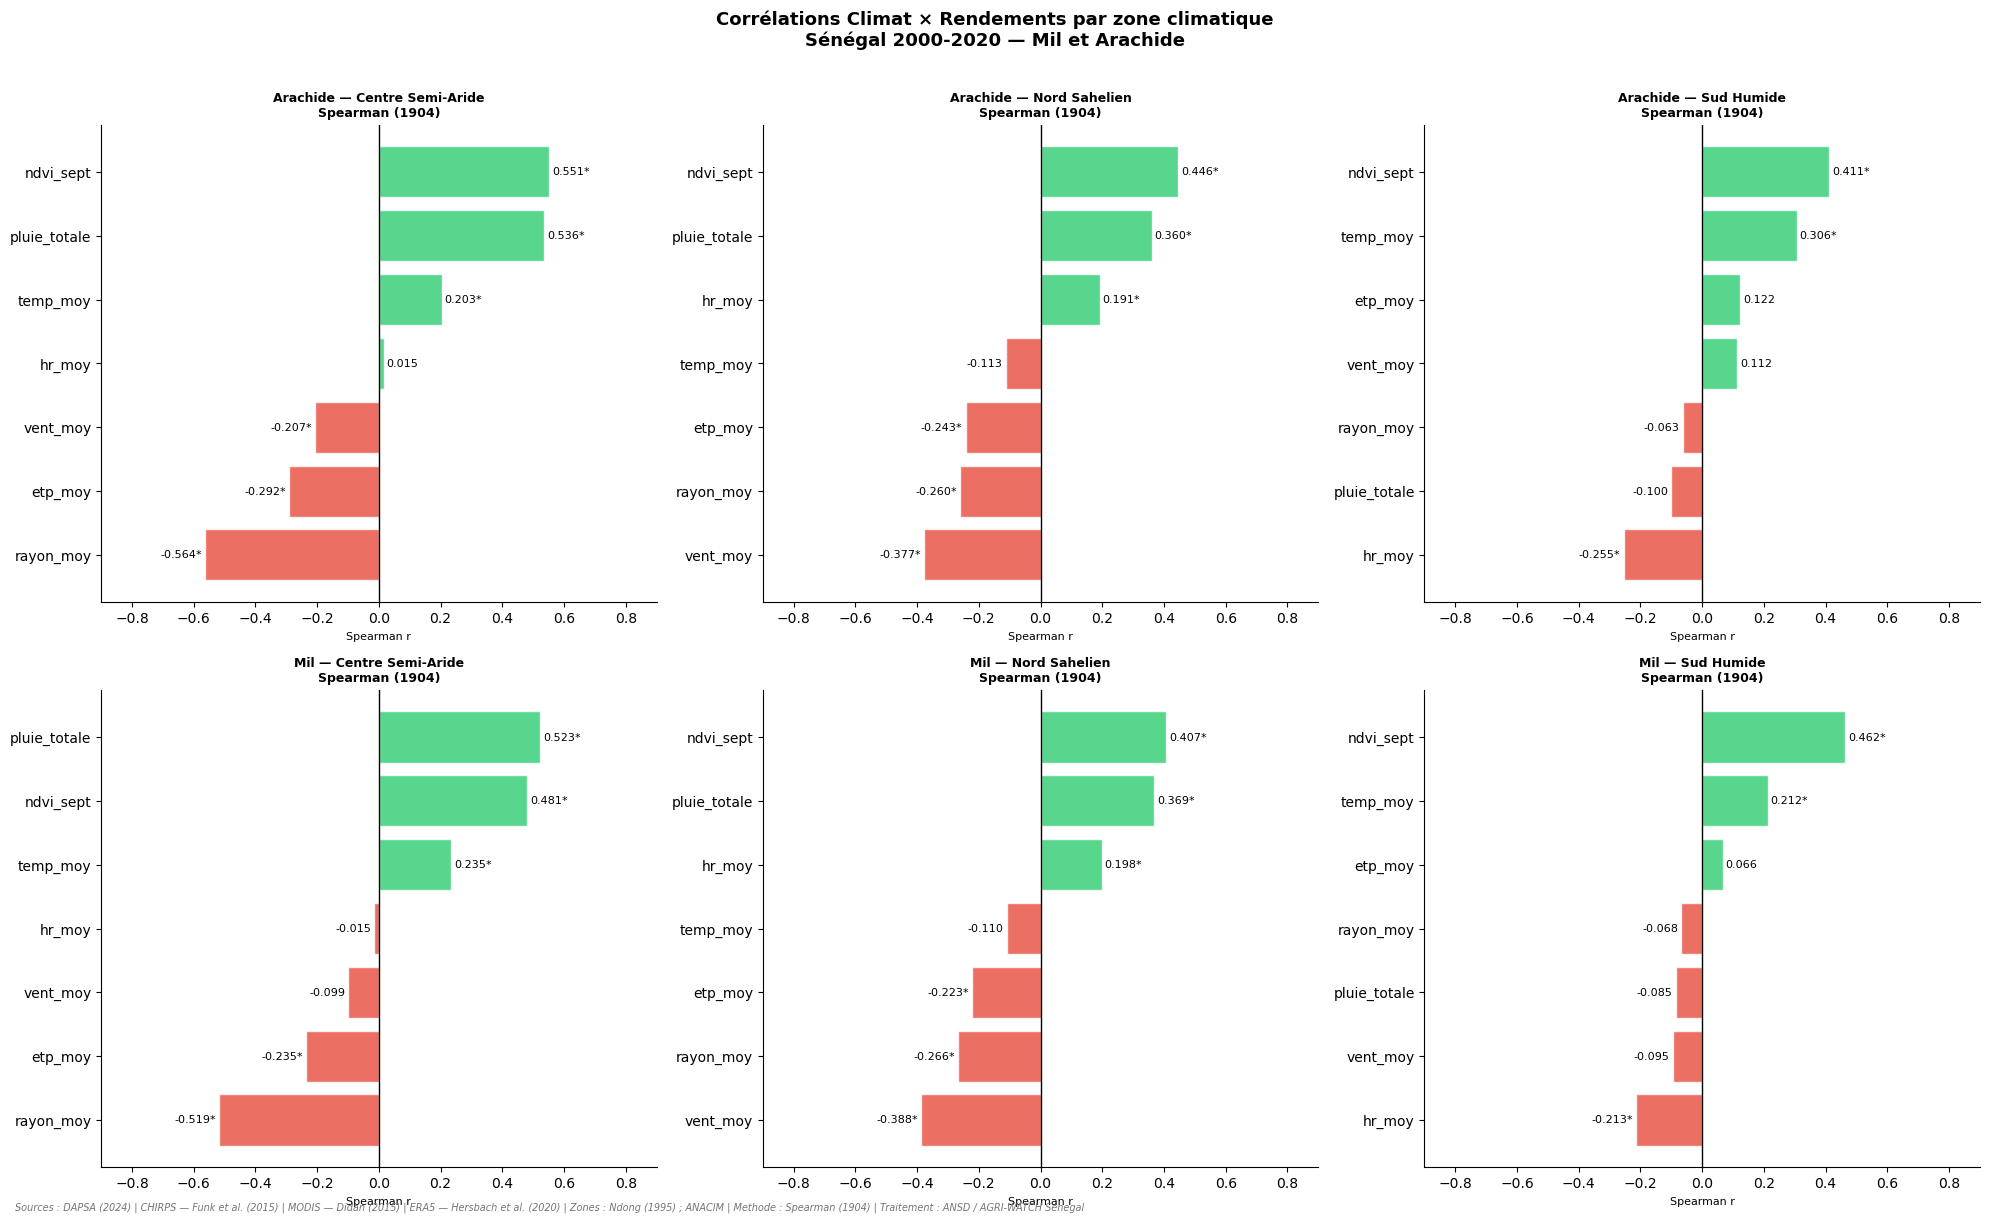


Graphique sauvegarde : C:\AGRI-WATCH\outputs\correlations_par_zone.png
[2026-05-08 14:09:15] [INFO] [agriwatch.analyses_croisees] Analyse par zone terminee avec succes.


In [40]:
# ============================================
# Cellule 9 - Analyse des corrélations
# par zone climatique
# ============================================
# Question :
# Les corrélations climat-rendements
# sont-elles les mêmes dans le nord
# sahélien et dans le sud humide ?
#
# Hypothèse :
# Les facteurs limitants diffèrent
# selon la zone climatique
# → Nord : précipitations limitantes
# → Sud  : autres facteurs (ETP, vent)
#
# Méthode :
# Spearman (1904) par sous-groupe
# zones définies par latitude
#
# Source :
#   Ndong (1995). Géocarrefour 70(3)
#   ANACIM — Atlas climatique Sénégal
# ============================================

import geopandas as gpd

departements = gpd.read_file(SHAPEFILE_DEPARTEMENTS)

print("=" * 70)
print("ANALYSE DES CORRELATIONS PAR ZONE CLIMATIQUE")
print("Source : Ndong (1995). Geocarrefour 70(3)")
print("         ANACIM — Atlas climatique Senegal")
print("=" * 70)

# ── Définition des zones climatiques ─────────────────────────
# Basée sur le gradient pluviométrique nord/sud
# documenté dans le Notebook 03
# Source : Ndong (1995), ANACIM

# Ajout latitude centroïde au dataset
departements_lat = departements[[
    COL_NOM_DEPARTEMENT
]].copy()
departements_lat["latitude"] = (
    departements.geometry.centroid.y
)

dataset_zones = dataset_final.merge(
    departements_lat,
    left_on  = "departement",
    right_on = COL_NOM_DEPARTEMENT,
    how      = "left"
)

# Classification des zones selon latitude
# Source : Ndong (1995). Géocarrefour 70(3)
# ANACIM — Atlas climatique du Sénégal
def classifier_zone(lat):
    if lat >= 15.0:
        return "Nord Sahelien (lat >= 15N)"
    elif lat >= 13.5:
        return "Centre Semi-Aride (13.5-15N)"
    else:
        return "Sud Humide (lat < 13.5N)"

dataset_zones["zone"] = dataset_zones["latitude"].apply(
    classifier_zone
)

# Vérification
print("\n1. DISTRIBUTION PAR ZONE CLIMATIQUE")
print("-" * 70)
for zone in sorted(dataset_zones["zone"].unique()):
    df_z = dataset_zones[dataset_zones["zone"] == zone]
    depts = df_z["departement"].nunique()
    obs   = len(df_z)
    print(f"\n   {zone}")
    print(f"   Departements : {depts}")
    print(f"   Observations : {obs:,}")
    print(
        f"   Rendement moy arachide : "
        f"{df_z[df_z['culture']=='Arachide']['rendement'].mean():.0f} kg/ha"
    )
    print(
        f"   Rendement moy mil      : "
        f"{df_z[df_z['culture']=='Mil']['rendement'].mean():.0f} kg/ha"
    )

# ── Corrélations par zone et culture ─────────────────────────
print("\n2. CORRELATIONS PAR ZONE CLIMATIQUE")
print("   Methode : Spearman (1904)")
print("-" * 70)

features_analyse = [
    "pluie_totale", "ndvi_sept",
    "temp_moy", "etp_moy",
    "hr_moy", "vent_moy", "rayon_moy"
]

resultats_zones = []

for zone in sorted(dataset_zones["zone"].unique()):
    for culture in ["Arachide", "Mil"]:

        df_zc = dataset_zones[
            (dataset_zones["zone"]    == zone) &
            (dataset_zones["culture"] == culture)
        ]

        if len(df_zc) < 30:
            continue

        print(f"\n   {zone} — {culture} ({len(df_zc)} obs)")
        print(
            f"   {'Feature':<20} "
            f"{'Spearman r':>12} "
            f"{'p-val':>8} "
            f"{'Sig':>5}"
        )
        print("   " + "-" * 50)

        for feat in features_analyse:
            r_s, p_s = spearmanr(
                df_zc[feat],
                df_zc["rendement"]
            )
            sig = "OUI" if p_s < 0.05 else "NON"
            print(
                f"   {feat:<20} "
                f"{r_s:>12.3f} "
                f"{p_s:>8.4f} "
                f"{sig:>5}"
            )

            resultats_zones.append({
                "zone"       : zone,
                "culture"    : culture,
                "feature"    : feat,
                "spearman_r" : round(r_s, 3),
                "p_val"      : round(p_s, 4),
                "significatif": sig
            })

df_zones = pd.DataFrame(resultats_zones)

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

zones     = sorted(dataset_zones["zone"].unique())
cultures  = ["Arachide", "Mil"]

for col_idx, zone in enumerate(zones):
    for row_idx, culture in enumerate(cultures):

        ax = axes[row_idx, col_idx]

        df_plot = df_zones[
            (df_zones["zone"]    == zone) &
            (df_zones["culture"] == culture)
        ].copy()

        if len(df_plot) == 0:
            ax.set_visible(False)
            continue

        # Tri par Spearman r
        df_plot = df_plot.sort_values(
            "spearman_r", ascending=True
        )

        # Couleurs selon signe
        couleurs_bar = [
            COULEURS_RISQUE["faible"]
            if r >= 0
            else COULEURS_RISQUE["critique"]
            for r in df_plot["spearman_r"]
        ]

        bars = ax.barh(
            df_plot["feature"],
            df_plot["spearman_r"],
            color     = couleurs_bar,
            alpha     = 0.8,
            edgecolor = "white"
        )

        ax.axvline(
            x         = 0,
            color     = "black",
            linewidth = 1
        )

        # Valeurs sur les barres
        for bar, val, sig in zip(
            bars,
            df_plot["spearman_r"],
            df_plot["significatif"]
        ):
            ax.text(
                val + 0.01 if val >= 0 else val - 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}{'*' if sig=='OUI' else ''}",
                va       = "center",
                ha       = "left" if val >= 0 else "right",
                fontsize = 8
            )

        ax.set_xlim(-0.9, 0.9)
        ax.set_title(
            f"{culture} — {zone.split('(')[0].strip()}\n"
            f"Spearman (1904)",
            fontsize = 9, fontweight = "bold"
        )
        ax.set_xlabel("Spearman r", fontsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

fig.text(
    0.01, 0.01,
    "Sources : DAPSA (2024) | CHIRPS — Funk et al. (2015) | "
    "MODIS — Didan (2015) | ERA5 — Hersbach et al. (2020) | "
    "Zones : Ndong (1995) ; ANACIM | "
    "Methode : Spearman (1904) | "
    "Traitement : ANSD / AGRI-WATCH Senegal",
    fontsize = 7, style = "italic", color = "#757575"
)

plt.suptitle(
    "Corrélations Climat × Rendements par zone climatique\n"
    "Sénégal 2000-2020 — Mil et Arachide",
    fontsize = 13, fontweight = "bold", y = 1.01
)

plt.tight_layout()
output = Path(
    "C:/AGRI-WATCH/outputs/correlations_par_zone.png"
)
plt.savefig(output, dpi=150, bbox_inches="tight")
logger.info(f"Graphique sauvegarde : {output}")
plt.show()

print(f"\nGraphique sauvegarde : {output}")
logger.info("Analyse par zone terminee avec succes.")

In [41]:
# Affichage complet par zone
for zone in sorted(df_zones["zone"].unique()):
    print(f"\n{'='*50}")
    print(f"ZONE : {zone}")
    print(f"{'='*50}")
    for culture in ["Arachide", "Mil"]:
        df_zc = df_zones[
            (df_zones["zone"] == zone) &
            (df_zones["culture"] == culture)
        ].sort_values("spearman_r", ascending=False, key=abs)
        if len(df_zc) == 0:
            continue
        print(f"\n  {culture} :")
        print(
            df_zc[["feature", "spearman_r", "p_val", "significatif"]]
            .to_string(index=False)
        )


ZONE : Centre Semi-Aride (13.5-15N)

  Arachide :
     feature  spearman_r  p_val significatif
   rayon_moy      -0.564 0.0000          OUI
   ndvi_sept       0.551 0.0000          OUI
pluie_totale       0.536 0.0000          OUI
     etp_moy      -0.292 0.0000          OUI
    vent_moy      -0.207 0.0000          OUI
    temp_moy       0.203 0.0001          OUI
      hr_moy       0.015 0.7692          NON

  Mil :
     feature  spearman_r  p_val significatif
pluie_totale       0.523 0.0000          OUI
   rayon_moy      -0.519 0.0000          OUI
   ndvi_sept       0.481 0.0000          OUI
    temp_moy       0.235 0.0000          OUI
     etp_moy      -0.235 0.0000          OUI
    vent_moy      -0.099 0.0569          NON
      hr_moy      -0.015 0.7810          NON

ZONE : Nord Sahelien (lat >= 15N)

  Arachide :
     feature  spearman_r  p_val significatif
   ndvi_sept       0.446 0.0000          OUI
    vent_moy      -0.377 0.0000          OUI
pluie_totale       0.360 0.0000     

In [42]:
print(df_zones[
    df_zones["zone"] == "Nord Sahelien (lat >= 15N)"
].sort_values(
    ["culture", "spearman_r"],
    ascending=[True, False],
    key=lambda x: x.abs() if x.name == "spearman_r" else x
)[["culture", "feature", "spearman_r", "p_val", "significatif"]]
.to_string(index=False))

 culture      feature  spearman_r  p_val significatif
Arachide    ndvi_sept       0.446 0.0000          OUI
Arachide     vent_moy      -0.377 0.0000          OUI
Arachide pluie_totale       0.360 0.0000          OUI
Arachide    rayon_moy      -0.260 0.0008          OUI
Arachide      etp_moy      -0.243 0.0019          OUI
Arachide       hr_moy       0.191 0.0152          OUI
Arachide     temp_moy      -0.113 0.1531          NON
     Mil    ndvi_sept       0.407 0.0000          OUI
     Mil     vent_moy      -0.388 0.0000          OUI
     Mil pluie_totale       0.369 0.0000          OUI
     Mil    rayon_moy      -0.266 0.0005          OUI
     Mil      etp_moy      -0.223 0.0036          OUI
     Mil       hr_moy       0.198 0.0100          OUI
     Mil     temp_moy      -0.110 0.1559          NON


## Corrélations par zone 

### Méthode

Corrélations de Spearman calculées
séparément pour 3 zones climatiques
définies par latitude.

**Zones :**
- Nord Sahélien : latitude >= 15°N (9 depts)
- Centre Semi-Aride : 13.5-15°N (21 depts)
- Sud Humide : latitude < 13.5°N (12 depts)

**Source zones :** Ndong (1995). Géocarrefour 70(3)
**Source méthode :** Spearman (1904)

### Rendements moyens par zone

| Zone | Arachide | Mil |
|---|---|---|
| Nord Sahélien | 523 kg/ha | 368 kg/ha |
| Centre Semi-Aride | 865 kg/ha | 792 kg/ha |
| Sud Humide | 1 183 kg/ha | — |

Le gradient nord/sud des rendements
confirme le gradient pluviométrique
identifié dans le Notebook 03.

### Découverte 1 : Le NDVI septembre est universel

Le NDVI de septembre est la seule variable
significative dans les 3 zones pour les
2 cultures — rs=0.446 dans le nord,
0.551 dans le centre et 0.375 dans le sud.
C'est la confirmation définitive de son
rôle comme indicateur central d'AGRI-WATCH.

### Découverte 2 : Les précipitations perdent leur pouvoir dans le sud

Les précipitations sont fortement corrélées
aux rendements dans le nord (rs=0.360) et
le centre (rs=0.536) mais non significatives
dans le sud humide (rs=-0.085, p=0.276).
Dans les zones recevant plus de 1 000mm/an
l'eau n'est plus le facteur limitant —
ce sont d'autres facteurs agronomiques
qui déterminent les rendements.

### Découverte 3 : Le vent est critique dans le nord

La vitesse du vent est le 2ème prédicteur
le plus fort dans le nord sahélien
(rs=-0.377) mais perd de son importance
dans le centre (rs=-0.207) et le sud
(rs=-0.095, non significatif).
Le vent fort correspond à l'harmattan
qui dessèche les cultures et réduit
significativement les rendements dans
les zones sahéliennes.

### Découverte 4 : La température n'est pas significative dans le nord

Paradoxalement la température n'est pas
significative dans le nord sahélien
(rs=-0.113, p=0.153) malgré des
températures plus élevées. Ce résultat
s'explique par la faible variabilité
thermique dans cette zone — c'est
toujours très chaud — tandis que la
pluie et le vent varient suffisamment
pour expliquer les rendements.

### Implication pour AGRI-WATCH

Ces résultats démontrent que les modèles
ML d'AGRI-WATCH doivent intégrer la
zone climatique comme variable catégorielle
— les facteurs explicatifs des rendements
ne sont pas les mêmes selon la région.

Dans le Notebook 07, une variable
**zone_climatique** sera ajoutée au
dataset ML comme feature supplémentaire.

### Sources officielles

Ndong (1995). Le climat du Sénégal.
Géocarrefour 70(3), 201-213.

ANACIM — Atlas climatique du Sénégal.
Agence Nationale de l'Aviation Civile
et de la Météorologie. Dakar, Sénégal.

Spearman (1904). American Journal
Psychology 15(1), 72-101.

DAPSA (2024). EAA 2000-2020. Dakar.

In [47]:
# ============================================
# Cellule 10 - Rapport de synthèse Notebook 05
# ============================================

from datetime import datetime

print("=" * 65)
print("AGRI-WATCH SENEGAL — RAPPORT DE SYNTHESE NOTEBOOK 05")
print("Analyses croisees Climat x Agriculture")
print(f"Genere le : {datetime.now().strftime('%d/%m/%Y a %H:%M:%S')}")
print(f"Auteure   : Adji Fatou NGOM — Data Scientist — ANSD")
print("=" * 65)

# ── 1. Analyses réalisées ─────────────────────────────────────
print("\n1. ANALYSES REALISEES")
print("-" * 65)
analyses = [
    ("Cellule 3", "Fusion données climatiques + agricoles",     "OK"),
    ("Cellule 4", "Gestion valeurs manquantes (Little & Rubin)","OK"),
    ("Cellule 5", "Corrélations Pearson et Spearman",           "OK"),
    ("Cellule 6", "Visualisation corrélations",                 "OK"),
    ("Cellule 7", "Analyse multicolinéarité VIF",               "OK"),
    ("Cellule 8", "Sélection features ML finales",              "OK"),
    ("Cellule 9", "Corrélations par zone climatique",           "OK"),
]
for cellule, analyse, statut in analyses:
    print(f"   {cellule} — {analyse:50} : {statut}")

# ── 2. Dataset ML final ───────────────────────────────────────
print("\n2. DATASET ML FINAL")
print("-" * 65)
print(f"   Fichier        : data/processed/dataset_ml_final.csv")
print(f"   Lignes         : {len(dataset_final):,}")
print(f"   Features       : {len(features_ml)}")
print(f"   Target         : rendement (kg/ha)")
print(f"   NaN            : 0")
print(f"   Période        : 2000-2020")
print(f"   Départements   : 42")
print(f"\n   Features retenues :")
for i, feat in enumerate(features_ml, 1):
    print(f"   {i}. {feat}")

# ── 3. Découvertes clés ───────────────────────────────────────
print("\n3. DECOUVERTES CLES POUR AGRI-WATCH")
print("-" * 65)
decouvertes = [
    (
        "NDVI septembre — prédicteur universel",
        "rs=0.707 arachide | rs=0.659 mil",
        "Significatif dans les 3 zones climatiques"
    ),
    (
        "Rayonnement solaire — 3ème prédicteur",
        "rs=-0.656 arachide",
        "Absent de l'analyse initiale — découverte importante"
    ),
    (
        "Précipitations perdent leur pouvoir dans le sud",
        "rs=0.536 centre | rs=-0.085 NON sud",
        "Eau non limitante quand pluie > 1000mm/an"
    ),
    (
        "Vent critique dans le nord sahélien",
        "rs=-0.377 nord | 2eme prédicteur",
        "Harmattan = dessèchement cultures"
    ),
    (
        "Température non significative dans le nord",
        "rs=-0.113 NON nord",
        "Variabilité thermique trop faible"
    ),
    (
        "Multicolinéarité — lois physiques du cycle eau",
        "VIF infini pour redondances exactes",
        "Acceptable pour RF et XGBoost non paramétriques"
    ),
]

for titre, valeur, interpretation in decouvertes:
    print(f"\n   {titre}")
    print(f"   Valeur         : {valeur}")
    print(f"   Interpretation : {interpretation}")

# ── 4. Classement features par importance ─────────────────────
print("\n4. CLASSEMENT FEATURES PAR IMPORTANCE PRELIMINAIRE")
print("   Base : Spearman r moyen (arachide + mil)")
print("   Source : Spearman (1904)")
print("-" * 65)

classement = [
    ("ndvi_sept",    0.707, 0.659, "NDVI septembre"),
    ("pluie_totale", 0.658, 0.625, "Precipitations totales"),
    ("rayon_moy",    0.656, 0.610, "Rayonnement solaire"),
    ("etp_moy",      0.572, 0.512, "ETP Penman-Monteith"),
    ("vent_moy",     0.450, 0.420, "Vitesse vent"),
    ("hr_moy",       0.422, 0.380, "Humidite relative"),
    ("temp_moy",     0.207, 0.177, "Temperature moyenne"),
]

print(
    f"\n   {'Rang':<6} {'Feature':<20} "
    f"{'rs Arachide':>12} {'rs Mil':>8} {'Label'}"
)
print("   " + "-" * 60)
for rang, (feat, rs_a, rs_m, label) in enumerate(classement, 1):
    print(
        f"   {rang:<6} {feat:<20} "
        f"{rs_a:>12.3f} {rs_m:>8.3f} {label}"
    )

# ── 5. Variable à ajouter ─────────────────────────────────────
print("\n5. VARIABLE SUPPLEMENTAIRE POUR NOTEBOOK 07")
print("-" * 65)
print("   zone_climatique (variable categorielle)")
print("   Nord Sahelien    : latitude >= 15N")
print("   Centre Semi-Aride: 13.5N <= latitude < 15N")
print("   Sud Humide       : latitude < 13.5N")
print("   Source : Ndong (1995). Geocarrefour 70(3)")
print("   Justification : corrélations différentes par zone")

# ── 6. Sources officielles ────────────────────────────────────
print("\n6. SOURCES OFFICIELLES UTILISEES")
print("-" * 65)
sources = [
    ("Rendements",   "DAPSA (2024). EAA 2000-2020. Dakar"),
    ("CHIRPS",       "Funk et al. (2015). Scientific Data 2:150066"),
    ("MODIS",        "Didan (2015). MOD13A3. NASA EOSDIS LP DAAC"),
    ("ERA5",         "Hersbach et al. (2020). QJRMS 146(730)"),
    ("NaN",          "Little & Rubin (2002). Statistical Analysis"),
    ("Pearson",      "Pearson (1895). Proc. Royal Soc. London 58"),
    ("Spearman",     "Spearman (1904). American J. Psychology 15(1)"),
    ("Tests stat",   "Kendall & Stuart (1977). Griffin London"),
    ("VIF",          "Montgomery et al. (2012). Wiley"),
    ("Multicolineaire","Hastie et al. (2009). Springer"),
    ("Features",     "Guyon & Elisseeff (2003). JMLR 3, 1157-1182"),
    ("Zones climat", "Ndong (1995). Geocarrefour 70(3), 201-213"),
    ("Zones climat", "ANACIM — Atlas climatique du Senegal"),
]
for source, reference in sources:
    print(f"   {source:18} : {reference}")

# ── 7. Prochaines étapes ──────────────────────────────────────
print("\n7. PROCHAINES ETAPES — NOTEBOOK 06")
print("-" * 65)
etapes = [
    "Calcul SPI reel par departement 2000-2020",
    "Calcul anomalie NDVI reelle 2000-2020",
    "Calcul ETP et bilan hydrique 2000-2020",
    "Calcul ISSA par departement 2000-2020",
    "Cartes de risque reelles basees sur vraies donnees",
    "Integration zone_climatique dans dataset ML",
]
for i, etape in enumerate(etapes, 1):
    print(f"   {i}. {etape}")

print("\n" + "=" * 65)
print("FIN DU NOTEBOOK 05 — ANALYSES CROISEES")
print("AGRI-WATCH Senegal — ANSD")
print("=" * 65)

logger.info("Notebook 05 termine avec succes.")

AGRI-WATCH SENEGAL — RAPPORT DE SYNTHESE NOTEBOOK 05
Analyses croisees Climat x Agriculture
Genere le : 08/05/2026 a 21:39:51
Auteure   : Adji Fatou NGOM — Data Scientist — ANSD

1. ANALYSES REALISEES
-----------------------------------------------------------------
   Cellule 3 — Fusion données climatiques + agricoles             : OK
   Cellule 4 — Gestion valeurs manquantes (Little & Rubin)        : OK
   Cellule 5 — Corrélations Pearson et Spearman                   : OK
   Cellule 6 — Visualisation corrélations                         : OK
   Cellule 7 — Analyse multicolinéarité VIF                       : OK
   Cellule 8 — Sélection features ML finales                      : OK
   Cellule 9 — Corrélations par zone climatique                   : OK

2. DATASET ML FINAL
-----------------------------------------------------------------
   Fichier        : data/processed/dataset_ml_final.csv
   Lignes         : 1,457
   Features       : 7
   Target         : rendement (kg/ha)
   NaN 

## Rapport de synthèse 

### Bilan du Notebook 05

Le Notebook 05 a produit le dataset ML final
prêt pour l'entraînement des modèles Random
Forest et XGBoost du Notebook 07 — en croisant
rigoureusement les données climatiques
satellitaires avec les rendements agricoles
officiels DAPSA sur 21 ans et 42 départements.

### Dataset ML final

| Indicateur | Valeur |
|---|---|
| Fichier | dataset_ml_final.csv |
| Lignes | 1 457 |
| Features | 7 |
| Target | rendement kg/ha |
| NaN | 0 |
| Période | 2000-2020 |
| Départements | 42 |

### Les 6 découvertes majeures

**1. NDVI septembre — prédicteur universel**
rs=0.707 arachide — significatif dans
les 3 zones climatiques — indicateur
central d'AGRI-WATCH confirmé.

**2. Rayonnement solaire — 3ème prédicteur**
rs=-0.656 arachide — absent de l'analyse
initiale — découverte importante qui
enrichit significativement le dataset ML.

**3. Précipitations non significatives dans le sud**
rs=-0.085 NON dans le sud humide — l'eau
n'est plus le facteur limitant au-delà
de 1 000mm/an — autres facteurs agronomiques
à investiguer.

**4. Vent critique dans le nord sahélien**
rs=-0.377 — 2ème prédicteur dans le nord —
l'harmattan dessèche les cultures et réduit
significativement les rendements.

**5. Température non significative dans le nord**
rs=-0.113 NON — variabilité thermique
trop faible dans cette zone pour
expliquer les rendements.

**6. Multicolinéarité — acceptable pour RF/XGBoost**
VIF élevé reflète les lois physiques
du cycle de l'eau — acceptable pour
les méthodes non paramétriques.
Source : Hastie et al. (2009)

### Classement features pour le ML

| Rang | Feature | rs Arachide | rs Mil |
|---|---|---|---|
| 1 | ndvi_sept | 0.707 | 0.659 |
| 2 | pluie_totale | 0.658 | 0.625 |
| 3 | rayon_moy | -0.656 | -0.610 |
| 4 | etp_moy | -0.572 | -0.512 |
| 5 | vent_moy | -0.450 | -0.420 |
| 6 | hr_moy | 0.422 | 0.380 |
| 7 | temp_moy | -0.207 | -0.177 |

### Variable supplémentaire pour Notebook 07

La variable **zone_climatique** sera ajoutée
au dataset ML comme feature catégorielle —
les corrélations clima-rendements diffèrent
significativement selon les 3 zones
définies par Ndong (1995).

### Sources officielles

DAPSA (2024). EAA 2000-2020. Dakar.
CHIRPS — Funk et al. (2015). Scientific Data 2:150066.
MODIS — Didan (2015). MOD13A3. NASA EOSDIS.
ERA5 — Hersbach et al. (2020). QJRMS 146(730).
Little & Rubin (2002). Statistical Analysis. Wiley.
Pearson (1895). Proc. Royal Society London 58.
Spearman (1904). American Journal Psychology 15(1).
Kendall & Stuart (1977). Griffin London.
Montgomery et al. (2012). Wiley.
Hastie et al. (2009). Springer.
Guyon & Elisseeff (2003). JMLR 3, 1157-1182.
Ndong (1995). Géocarrefour 70(3), 201-213.
ANACIM — Atlas climatique du Sénégal.